# Figure 5 - Transcription-linked Chromatin Deconvolution Results

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pipeline.figure_chromatin_metrics import FigureChromatinMetrics

fig_metrics = FigureChromatinMetrics(output_dir='output/draft4_run/')

In [3]:
fig_metrics.setup_processor()

Starting full expression analysis workflow...
Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints
Computing PTR values with quantiles 0.1-0.9...
Computed PTR values for 9663 transcripts
PTR range: 1.000 - 8.258
Identified 578 top cycling genes
PTR threshold: 1.168
Top cycling PTR range: 1.168 - 8.258
Loading saved data from output/draft4_run//chromatin_metrics...
  Loading deconvolved data...
    Loaded promoter_occupancy: 9663 genes, 257 timepoints
    Loaded nucleosome_entropy: 9663 genes, 257 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 257 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep1 data...
    Loaded promoter_occupancy: 9663 genes, 16 timepoints
    Loaded nucleosome_entrop

In [4]:
fig_metrics.setup_integration()

promoter_occupancy: n=5774, Pearson r=0.039 (p=2.80e-03), Spearman r=0.037 (p=5.14e-03)
nucleosome_entropy: n=5774, Pearson r=0.093 (p=1.57e-12), Spearman r=0.095 (p=6.12e-13)
nucleosome_occupancy: n=5774, Pearson r=0.080 (p=9.22e-10), Spearman r=0.090 (p=8.37e-12)


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnin

promoter_occupancy: n=5774, Pearson r=0.010 (p=4.48e-01), Spearman r=0.007 (p=5.71e-01)
nucleosome_entropy: n=5774, Pearson r=0.056 (p=1.80e-05), Spearman r=0.030 (p=2.11e-02)
nucleosome_occupancy: n=5774, Pearson r=0.033 (p=1.19e-02), Spearman r=0.104 (p=1.81e-15)
promoter_occupancy: n=5774, Pearson r=0.009 (p=5.05e-01), Spearman r=-0.002 (p=8.88e-01)
nucleosome_entropy: n=5774, Pearson r=0.051 (p=1.10e-04), Spearman r=0.020 (p=1.21e-01)
nucleosome_occupancy: n=5774, Pearson r=0.021 (p=1.05e-01), Spearman r=0.098 (p=6.84e-14)


In [5]:
from pipeline.chromatin_metrics_4d_analysis import ChromatinMetrics4D

metrics_4d = ChromatinMetrics4D(fig_metrics)
metrics_4d.initialize_tf_processor()

5 genes with nan values were removed
Creating directory: output/draft4_run//chromatin_metrics/clustering...Directory exists. Skipping.
Creating directory: output/draft4_run//figures_transcription_factors...Directory exists. Skipping.
Loading gene promoter data...
Loaded 5774 gene promoters
Loading TF binding datasets...
Number of total factors profiled by Rossi:  319
Number of TFs selected by GO terms (GO:0016563,GO:0043565):  166
Number of TFs with Rossi binding sites:  76
   of these, Kelliher cell-cycle TFS:  12
Found 2793 high-confidence binding sites for 76 cell cycle TFs
Loaded basic results from: output/draft4_run//figures_transcription_factors/binding_results.csv
Loaded comprehensive results from: output/draft4_run//figures_transcription_factors/full_results.csv
Using saved comprehensive results. Use force_recompute=True to regenerate.
Finding TF-gene associations...
Found gene associations for 713/2793 TF binding sites
Integrating gene association data...


Saved figure to: output/draft4_run//chromatin_metrics/clustering/diameters_hist.png
Saved figure to: output/draft4_run//chromatin_metrics/clustering/ptrs_diameter_cutoff.png


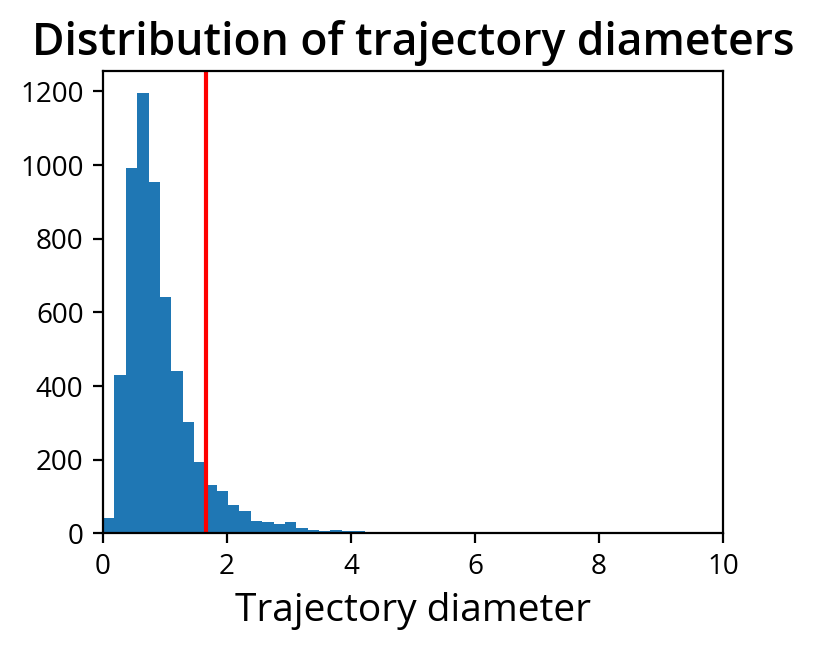

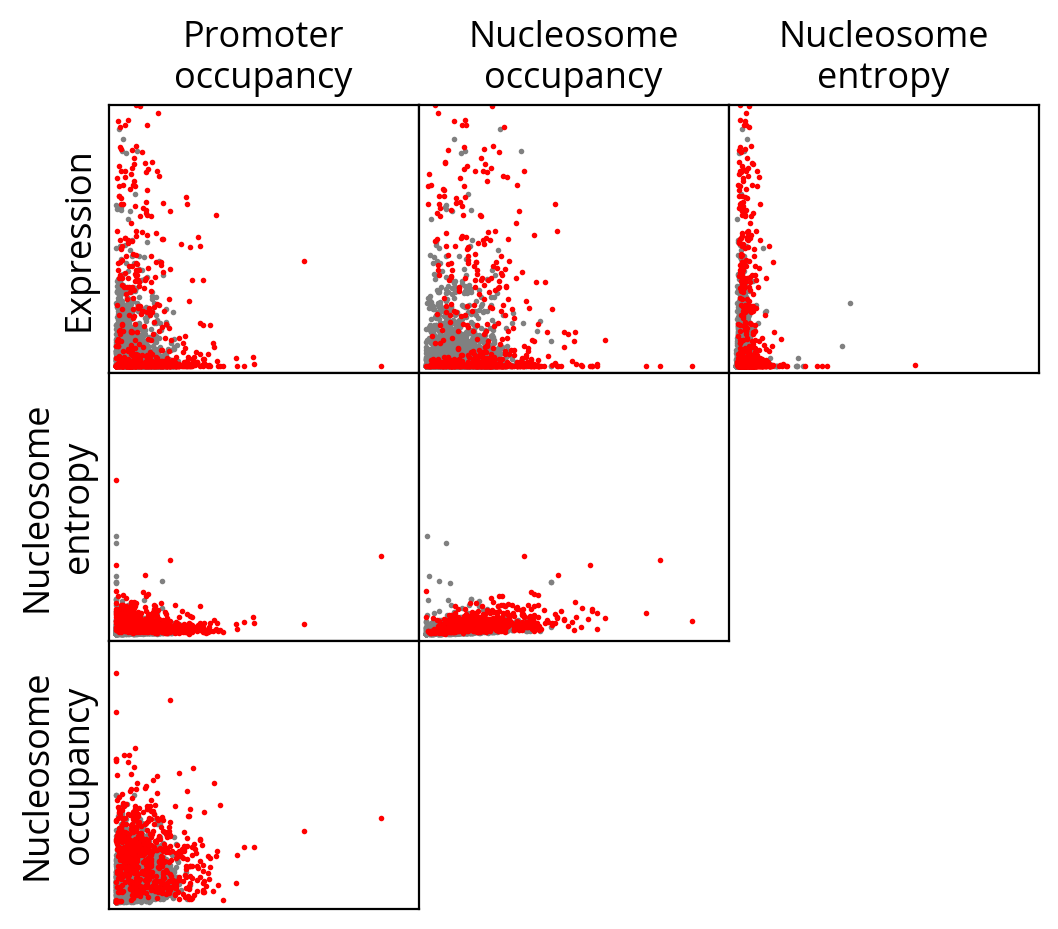

<Figure size 900x600 with 0 Axes>

In [6]:
metrics_4d.threshold_metrics_by_diameter()

The optimal_ke optimal k for clustering is:  20
Saved figure to: k_elbow.png


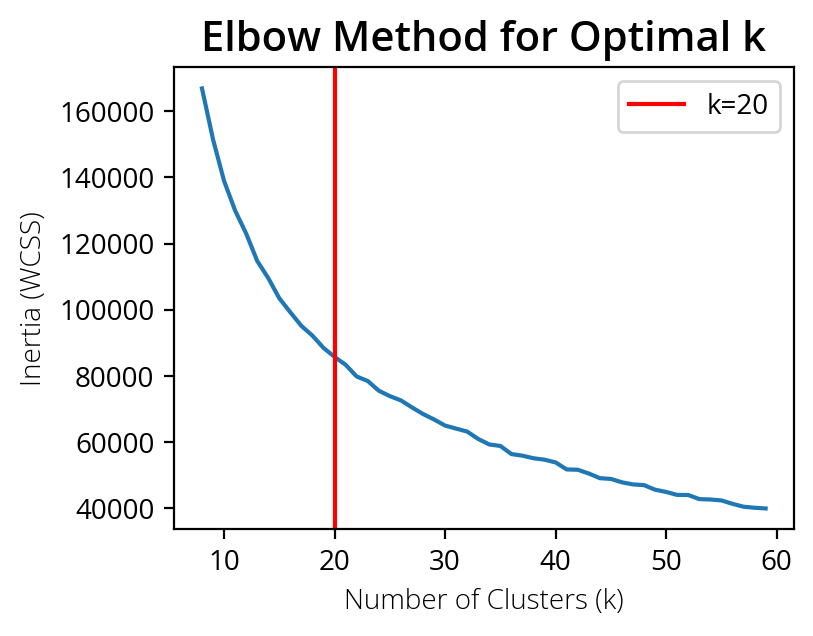

In [7]:
metrics_4d.kmeans_determine_k()

In [8]:
_ = metrics_4d.kmeans_cluster()

In [9]:
metrics_4d.run_go_clusters()

./data/goslim_yeast.obo: fmt(1.2) rel(go/2024-09-08/subsets/goslim_yeast.owl) 296 Terms


In [10]:
metrics_4d.sig_results[['id', 'name', 'fdr_bh', 'study_items']]

,id,name,fdr_bh,study_items
cluster,,,,
11,GO:0003677,DNA binding,0.000015,"HHT1,HTA2,YOX1,YHP1,HTB2,HTA1,HTB1,SWI4,HHF1"
11,GO:0006325,chromatin organization,0.001850,"HHT1,HTA2,HTB2,HTA1,HTB1,HHF1"
13,GO:0006260,DNA replication,0.000053,"RFA1,RFA2,TOF1,POL1,MRC1"
13,GO:0006281,DNA repair,0.003103,"RFA1,SMC6,MRC1,TOF1,RAD53,RFA2"


In [11]:
metrics_4d.sig_results[['id', 'name', 'fdr_bh', 'study_items']]#.loc[9].study_items.values

,id,name,fdr_bh,study_items
cluster,,,,
11,GO:0003677,DNA binding,0.000015,"HHT1,HTA2,YOX1,YHP1,HTB2,HTA1,HTB1,SWI4,HHF1"
11,GO:0006325,chromatin organization,0.001850,"HHT1,HTA2,HTB2,HTA1,HTB1,HHF1"
13,GO:0006260,DNA replication,0.000053,"RFA1,RFA2,TOF1,POL1,MRC1"
13,GO:0006281,DNA repair,0.003103,"RFA1,SMC6,MRC1,TOF1,RAD53,RFA2"


In [13]:
metrics_4d.perform_tf_analysis_of_clusters()

Only include TFs with at 2 or more total sites in the set.
Filtering from 121 sites to 90.


Creating directory: output/draft4_run//chromatin_metrics/clustering/trajectories...Directory exists. Skipping.
Cluster 1
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/meta_cluster_1.png
Cluster 11
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/meta_cluster_11.png
Cluster 13
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/meta_cluster_13.png


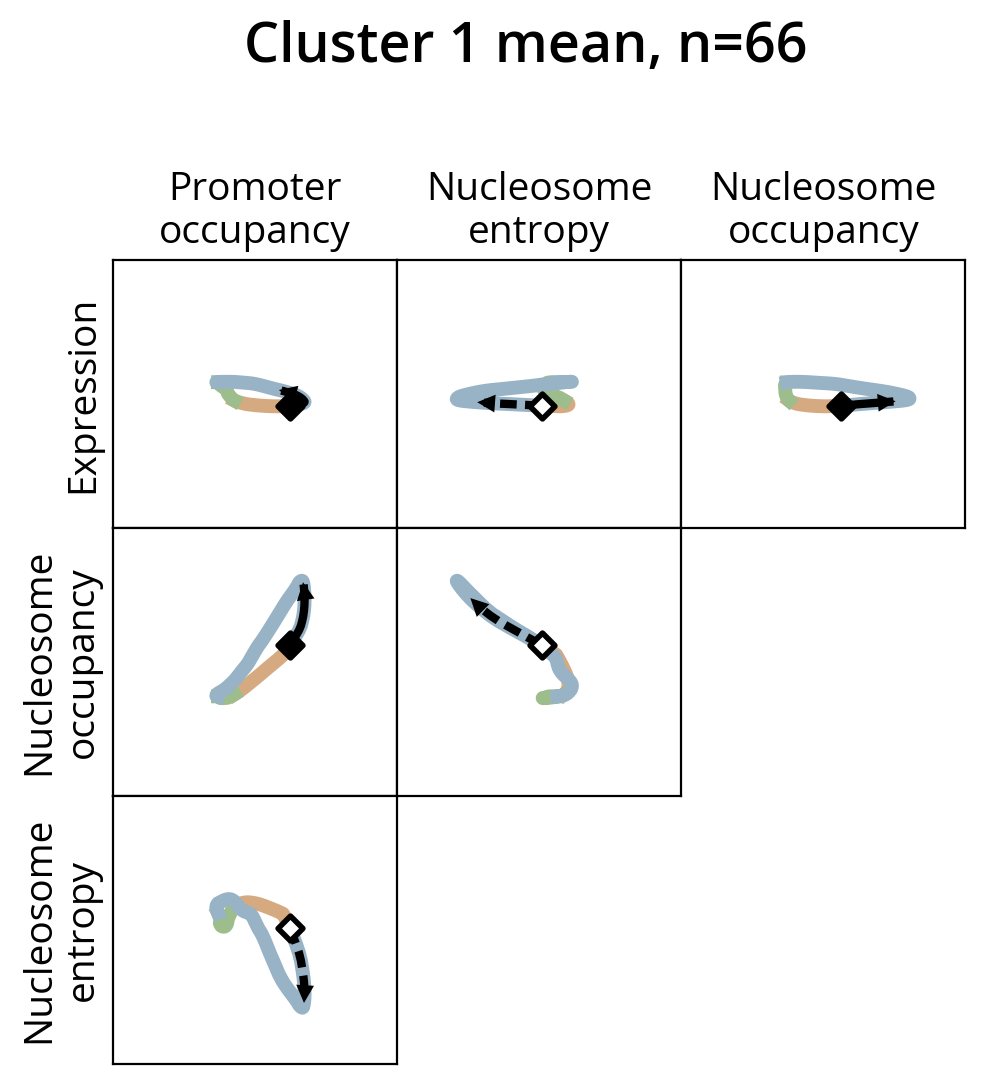

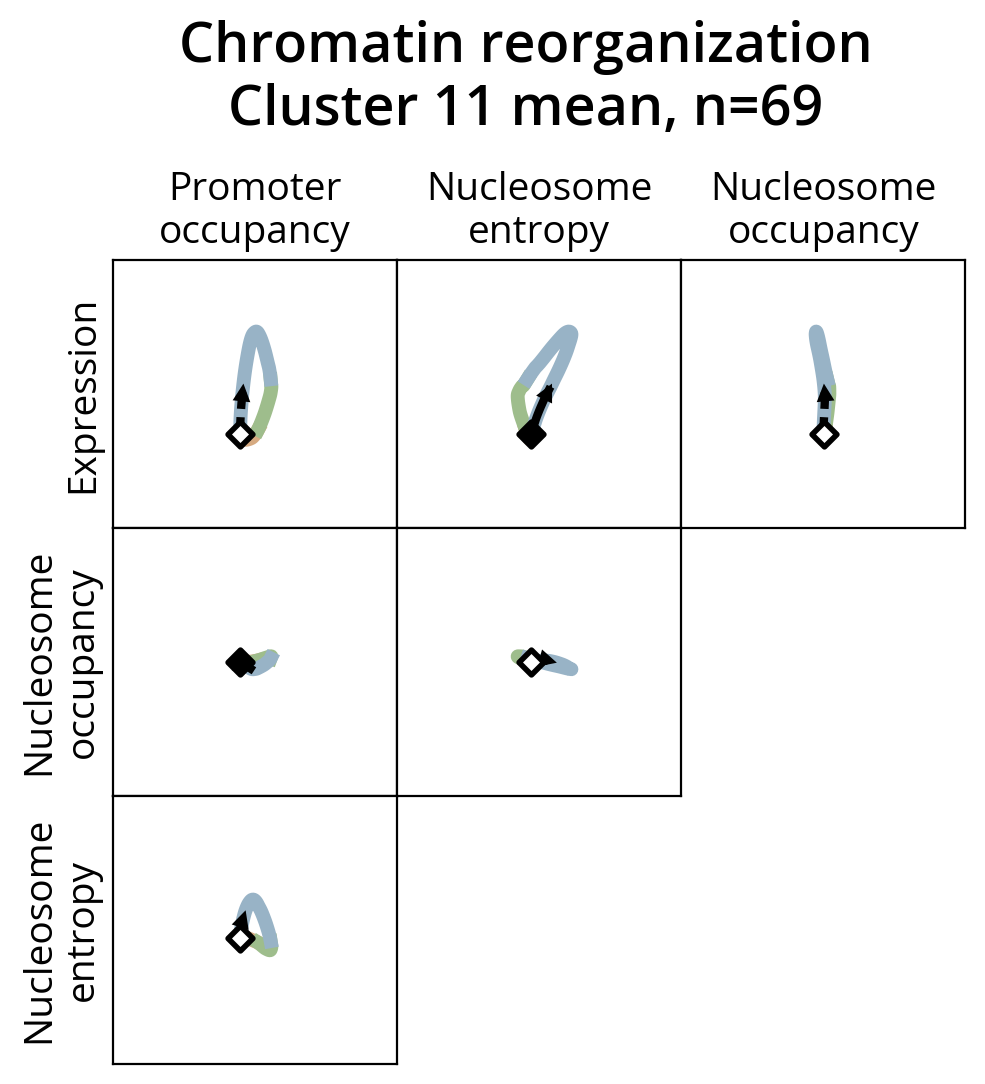

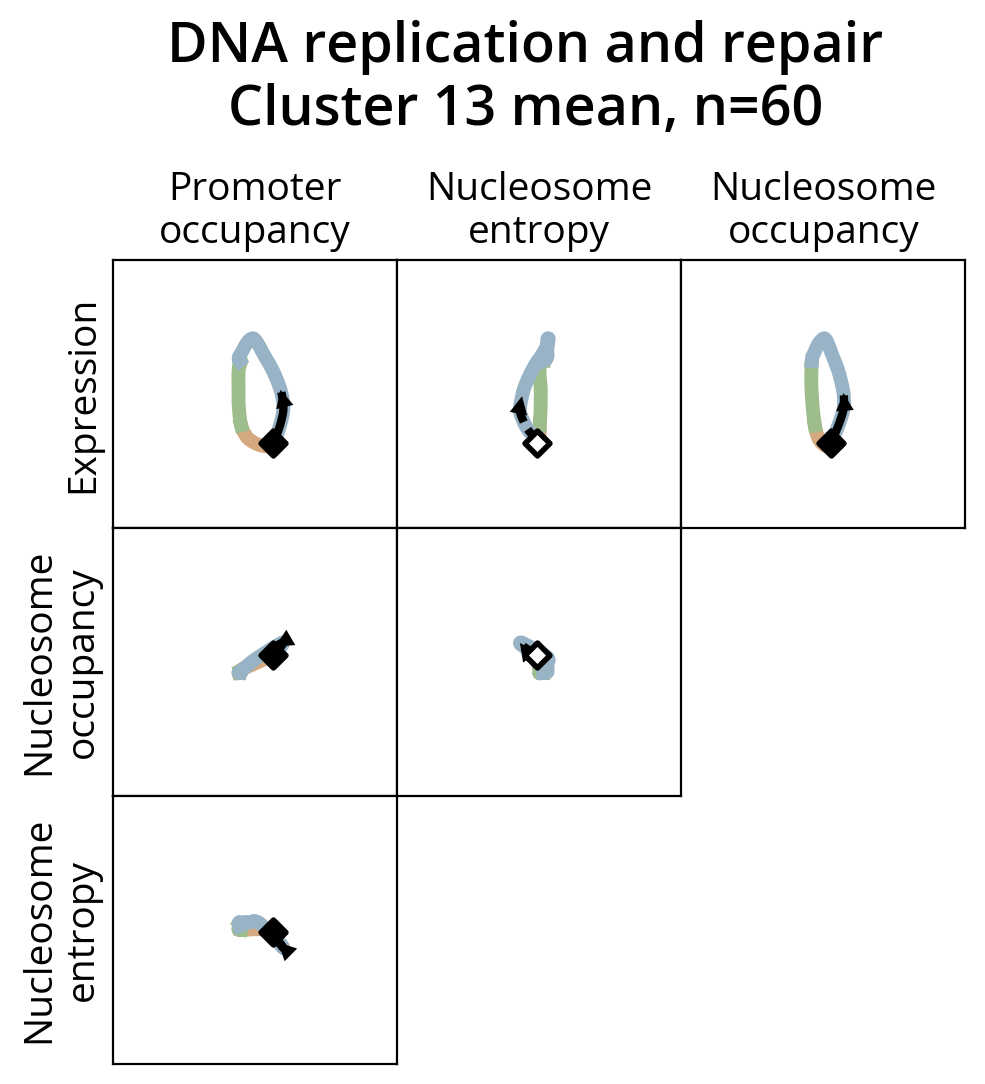

In [15]:
metrics_4d.plot_cluster_trajectories()

Saved figure to: output/draft4_run//chromatin_metrics/clustering/clusters_heatmap.png


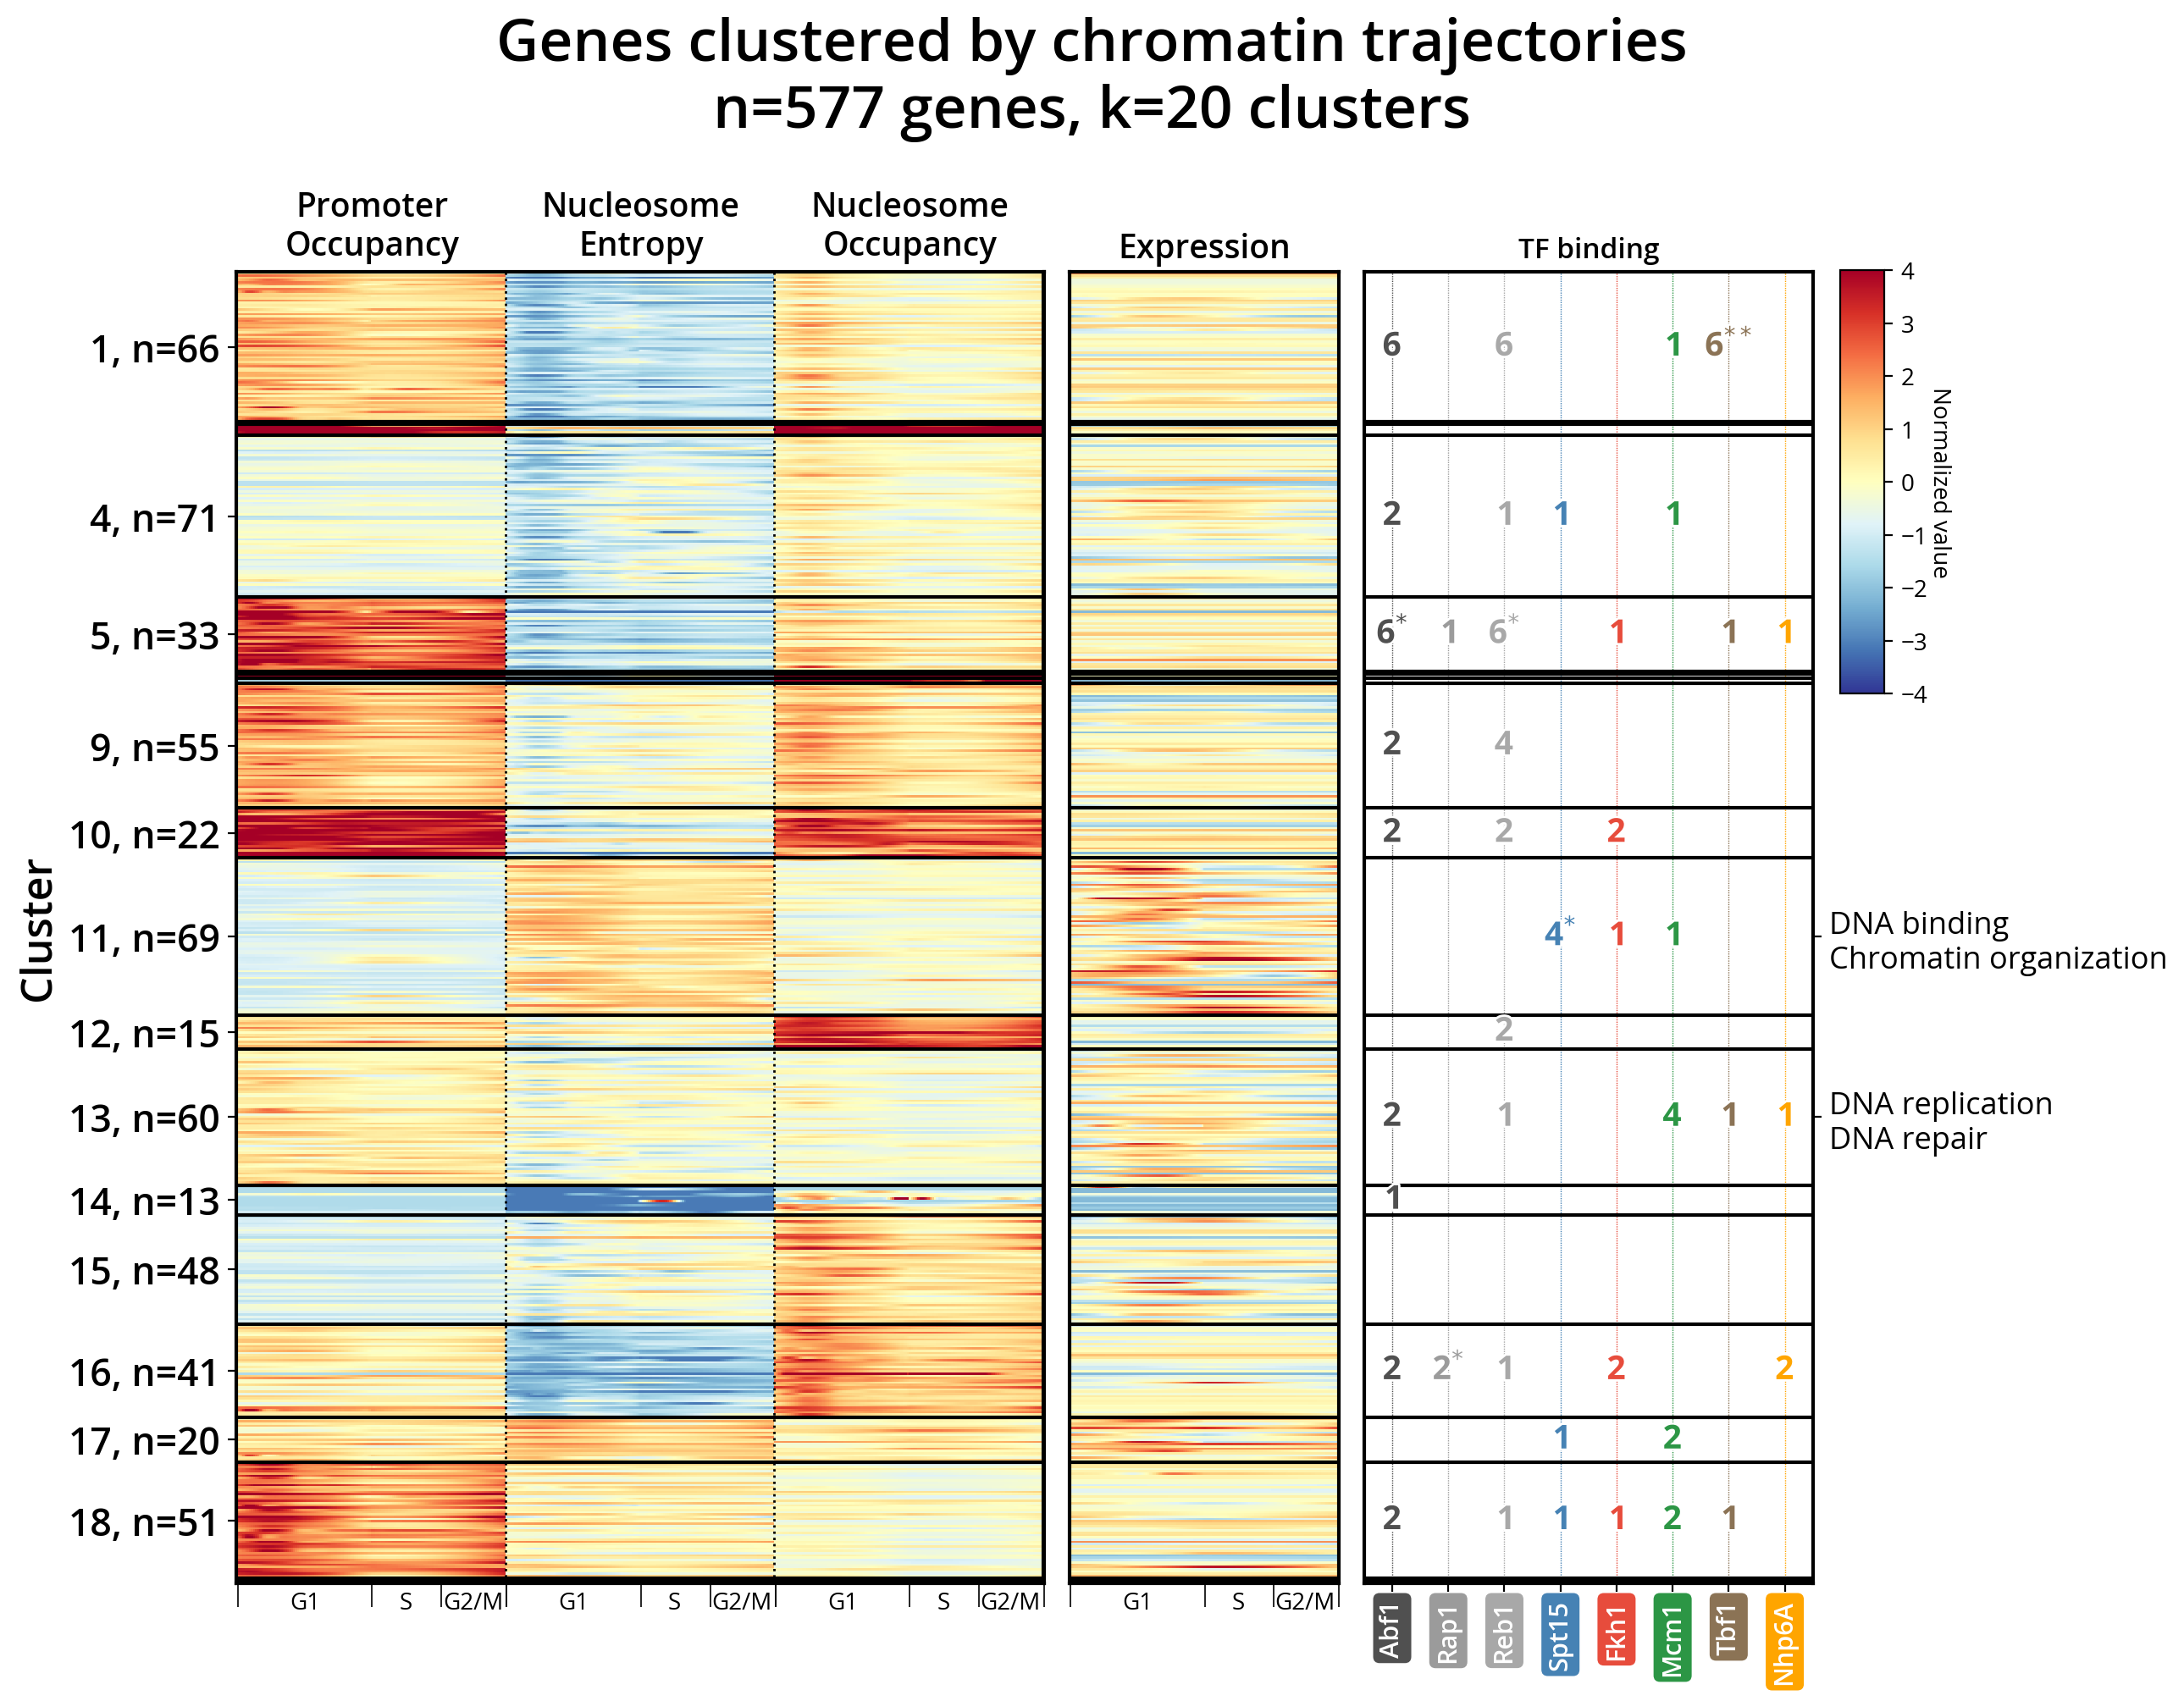

In [16]:
metrics_4d.plot_heatmap_of_clusters()

In [17]:
metrics_4d.sig_results.to_csv(f"{metrics_4d.save_dir}/go_enriched_clusters.csv")
metrics_4d.sig_results

,id,name,pop_count,pop_n,study_count,study_n,pop_items,study_items,fdr_bh,bonferroni
cluster,,,,,,,,,,
11,GO:0003677,DNA binding,83.0,5578.0,9.0,62.0,"SWC4,UME6,OAF1,IOC3,MIP1,FUN30,HHT1,MBP1,XRS2,...","HHT1,HTA2,YOX1,YHP1,HTB2,HTA1,HTB1,SWI4,HHF1",0.000015,0.000030
11,GO:0006325,chromatin organization,60.0,5578.0,6.0,62.0,"SPT2,PAA1,SWC4,ARP4,NGG1,SPT5,HIR2,GCN5,RNT1,E...","HHT1,HTA2,HTB2,HTA1,HTB1,HHF1",0.001850,0.005550
13,GO:0006260,DNA replication,17.0,5578.0,5.0,55.0,"CCR4,PRI2,MEC1,RFA1,POL5,RFA2,RRM3,SLX4,ECO1,A...","RFA1,RFA2,TOF1,POL1,MRC1",0.000053,0.000053
13,GO:0006281,DNA repair,69.0,5578.0,6.0,55.0,"HRR25,EPL1,NEJ1,RFC1,SWC4,ARP4,EAF7,NSE4,OGG1,...","RFA1,SMC6,MRC1,TOF1,RAD53,RFA2",0.003103,0.006206


Saved figure to: output/draft4_run//chromatin_metrics/clustering/example_annotated_trajectory.png


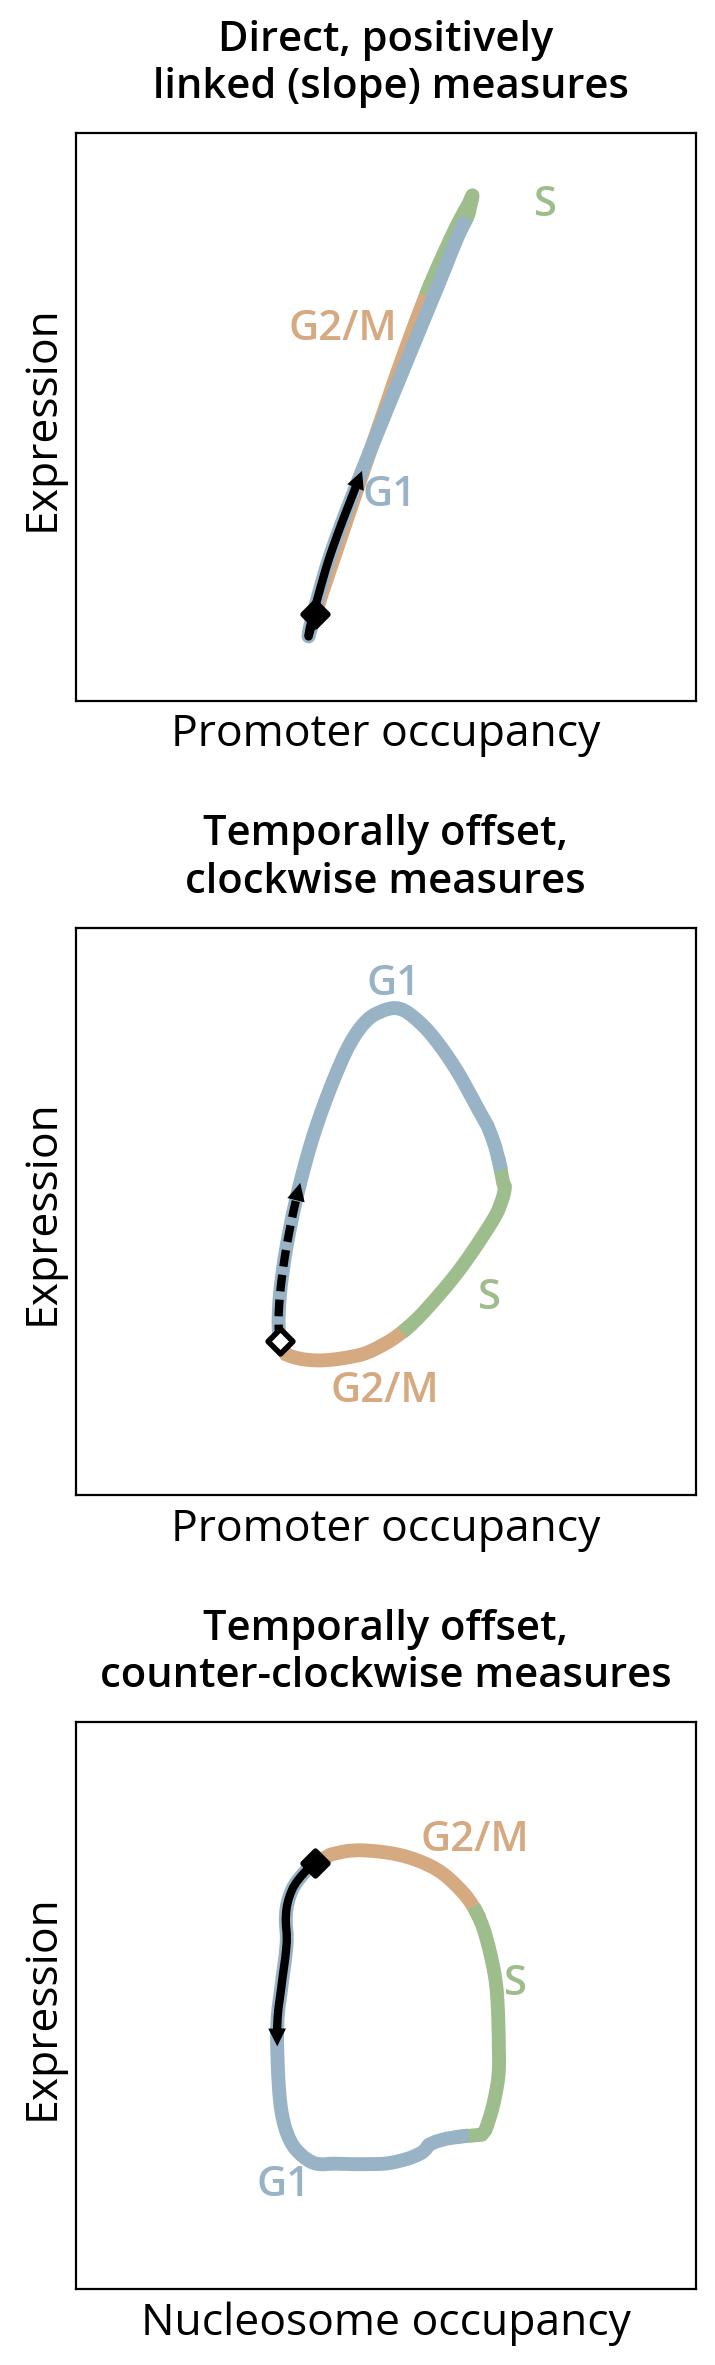

In [29]:
metrics_4d.plot_trajectories_example()

In [30]:
metrics_4d.layout_chromatin_transcription_figure()

Debug figure saved to: output/draft4_run/Figures/Debug/Figure5_Chromatin_Transcription_debug.png
Clean figure saved to: output/draft4_run/Figures/Figure5_Chromatin_Transcription.png
Uppercase figure saved to: output/draft4_run/Figures/Uppercase/Figure5_Chromatin_Transcription.png
Panel layout saved to: output/draft4_run/Figures/Figure5_Chromatin_Transcription.png


'output/draft4_run/Figures/Figure5_Chromatin_Transcription.png'

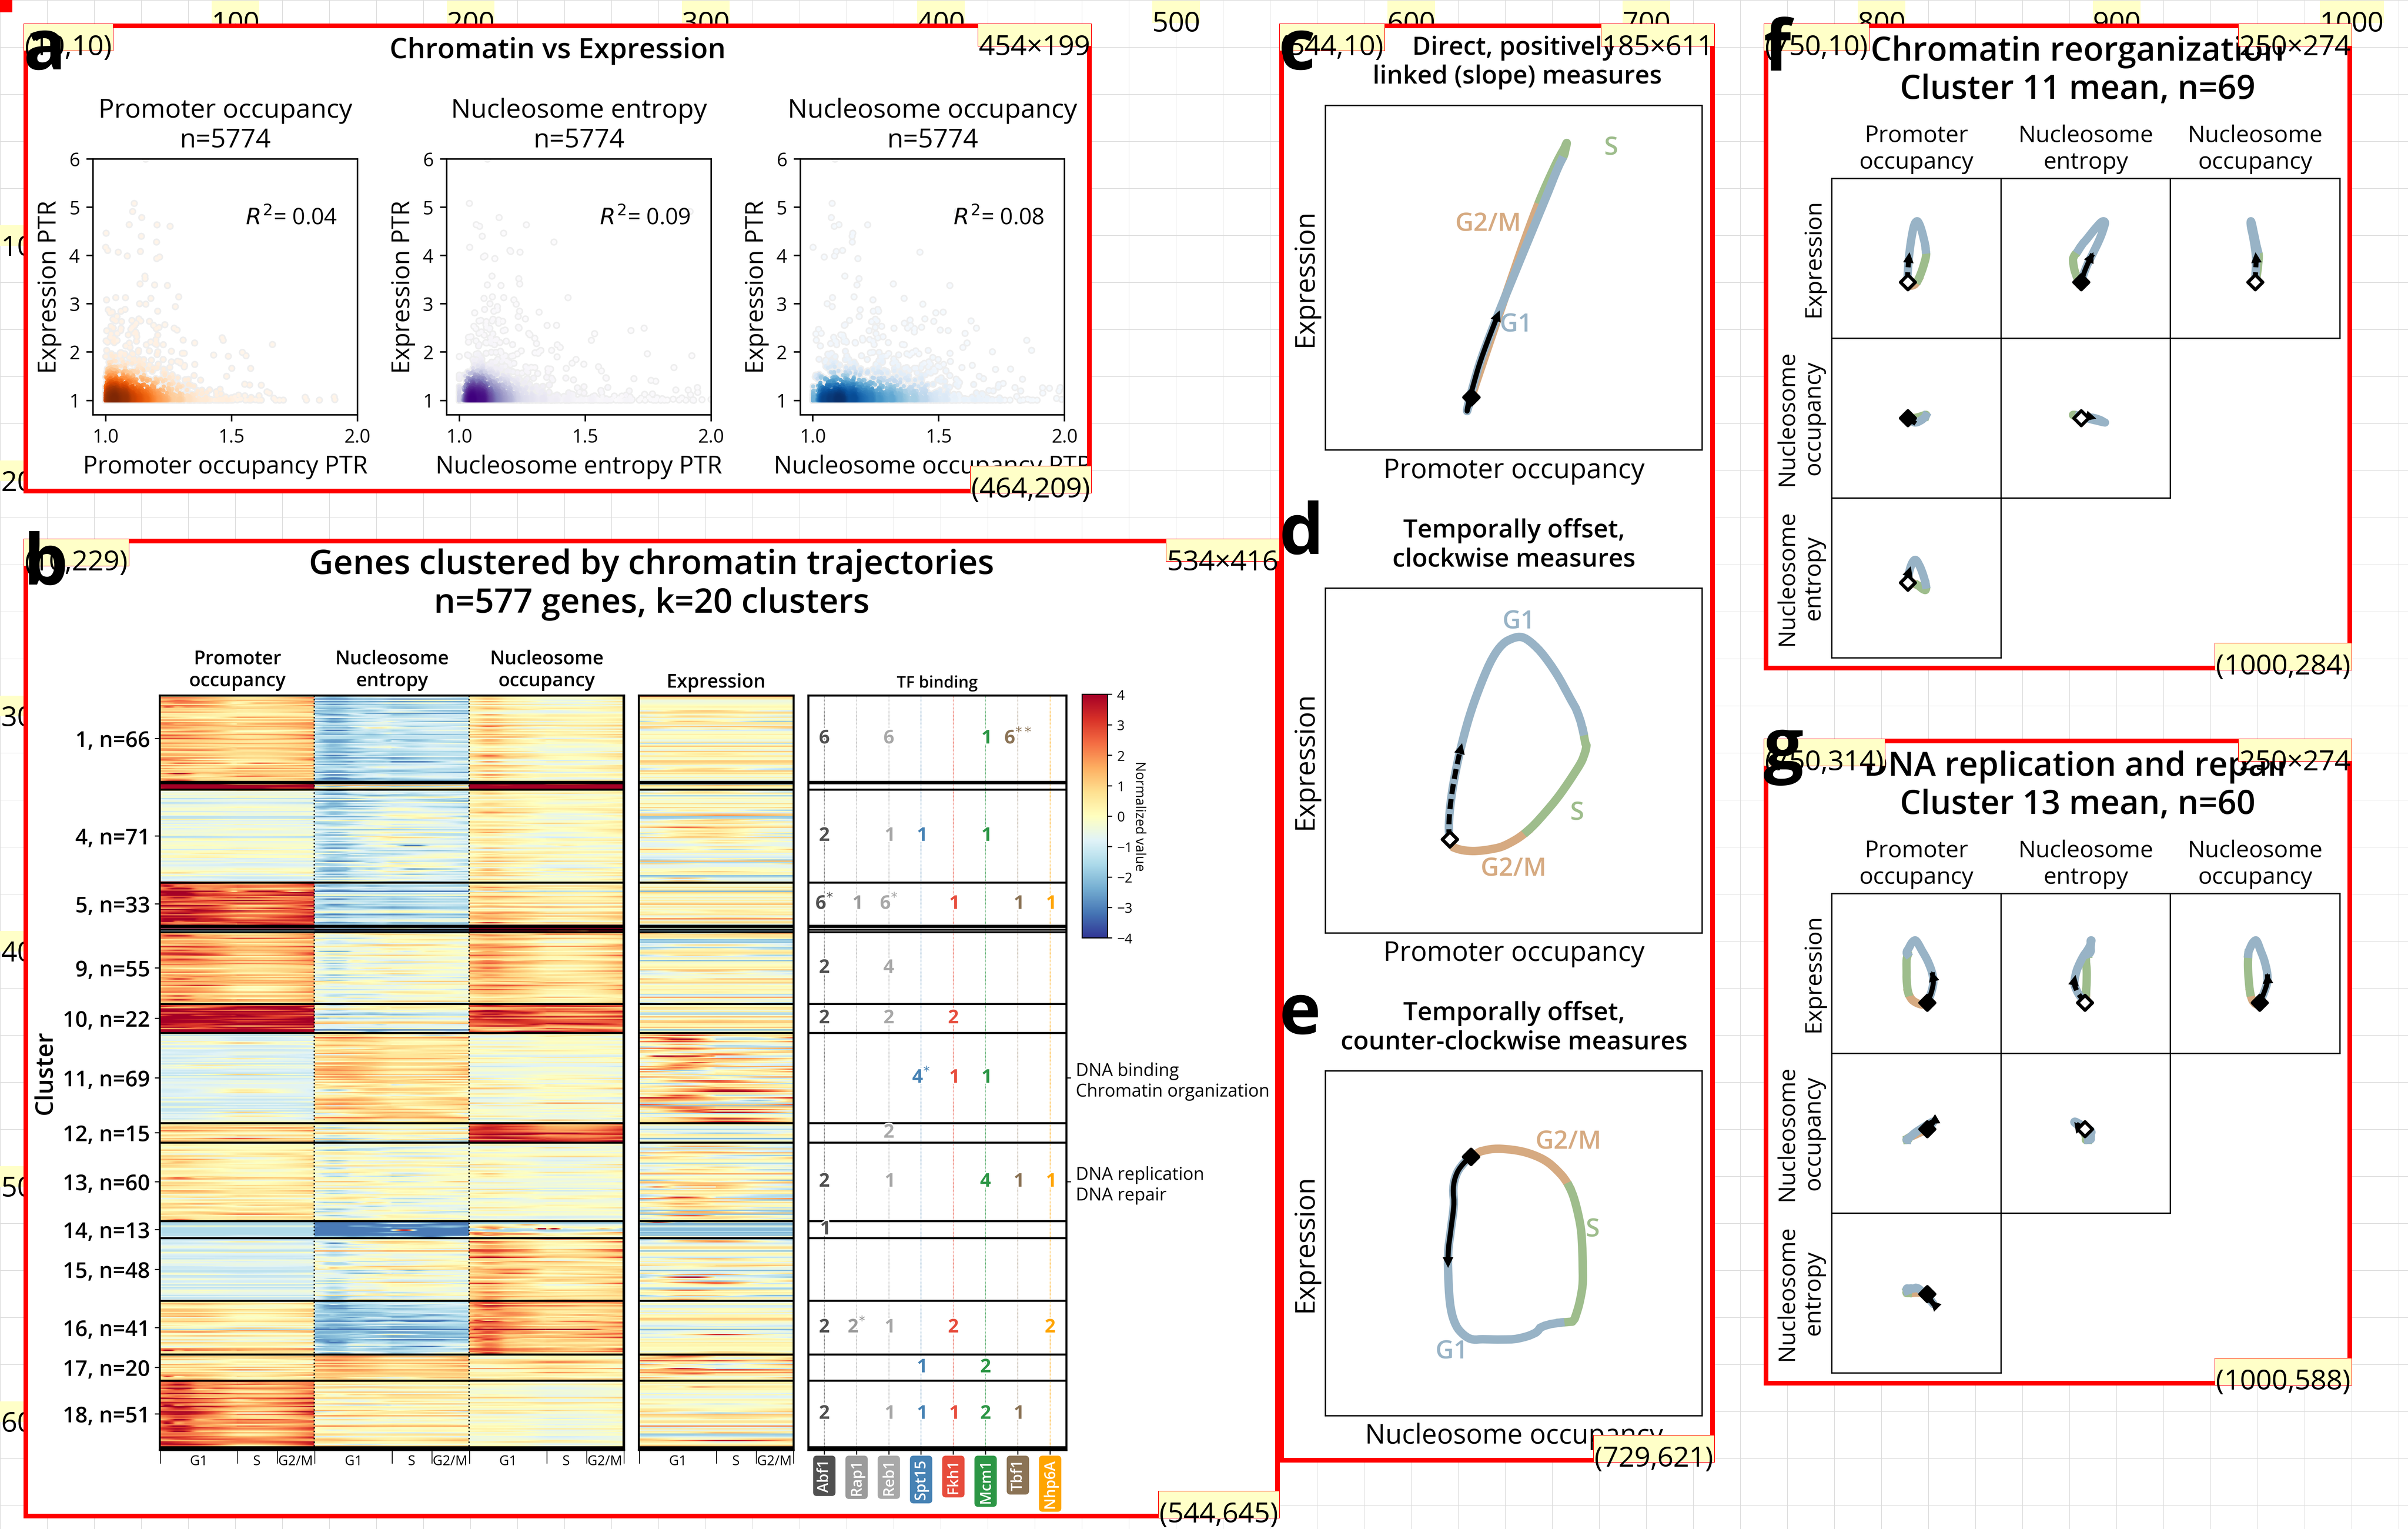

In [31]:
from IPython.display import Image, display
display(Image(f'output/draft4_run/Figures/Debug/Figure5_Chromatin_Transcription_debug.png'))